In [56]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [57]:
#Load the dataset
from google.colab import files

uploaded = files.upload()

Saving diabetes_screening_data.csv to diabetes_screening_data (2).csv


In [58]:
df = pd.read_csv("diabetes_screening_data.csv")

In [59]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [60]:
df.shape

(768, 9)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [62]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [63]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


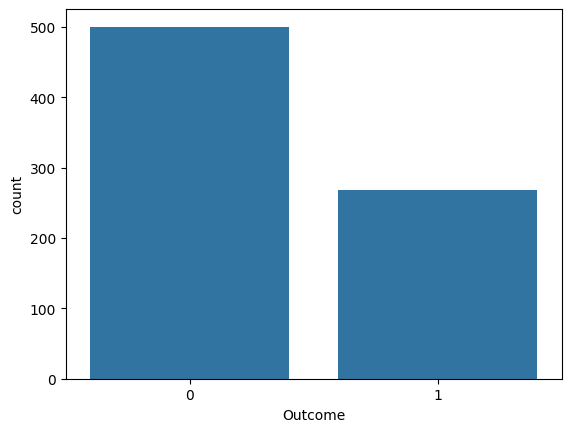

In [64]:
sns.countplot(x="Outcome", data=df)
plt.show()

In [65]:
#seperate x,y
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [66]:
print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [67]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[zero_columns] = df[zero_columns].replace(0, np.nan)

In [68]:
for column in zero_columns:
    df[column] = df[column].fillna(df[column].median())

In [69]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [70]:
#split training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [71]:
#scale the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
scaler.fit_transform(X_train)

array([[-0.85135507, -1.05642747, -0.82674004, ..., -0.76947697,
         0.31079384, -0.79216928],
       [ 0.35657564,  0.14439907,  0.47777235, ..., -0.41749769,
        -0.11643851,  0.56103382],
       [-0.5493724 , -0.55608308, -1.15286813, ...,  0.3597899 ,
        -0.76486207, -0.70759409],
       ...,
       [-0.85135507, -0.82293342, -0.17448384, ...,  0.82909561,
        -0.78607218, -0.28471812],
       [ 1.86648903, -0.35594533, -0.17448384, ..., -0.72547956,
        -1.01938346,  0.56103382],
       [ 0.05459296,  0.74481233, -1.15286813, ..., -0.43216349,
        -0.57700104,  0.30730824]])

In [73]:
scaler.transform(X_test)

array([[ 0.96054099,  1.24515673, -0.66367599, ..., -0.74014536,
        -0.55579092,  0.56103382],
       [ 1.86648903, -1.79026591,  2.76066903, ...,  0.44778472,
        -0.58306107,  1.15306018],
       [-0.5493724 ,  0.01097389,  0.3147083 , ...,  0.50644793,
         0.01688223, -0.6230189 ],
       ...,
       [-0.5493724 , -1.32327781, -1.64206028, ..., -0.57882152,
         3.70138246, -0.70759409],
       [ 0.05459296,  2.07906404,  0.47777235, ...,  0.66777177,
        -0.64669142, -0.20014293],
       [-0.85135507, -1.69019703,  0.47777235, ...,  0.11047124,
        -0.16794879, -1.04589487]])

In [74]:
#Train multiple algorithms
# 1.Logistic Regressions
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)


In [75]:
#KNN Algorithm
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [76]:
#Decision tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [77]:
#Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [78]:
#svm
svm = SVC(probability=True, random_state=42)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [79]:
#Creating a comprehension Table
models = {
    "Logistic Regression": (lr_pred, y_test),
    "KNN": (knn_pred, y_test),
    "Decision Tree": (dt_pred, y_test),
    "Random Forest": (rf_pred, y_test),
    "SVM": (svm_pred, y_test)
}

results = []

for name, (pred, actual) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(actual, pred),
        "Precision": precision_score(actual, pred),
        "Recall": recall_score(actual, pred),
        "F1 Score": f1_score(actual, pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Recall",
    ascending=False
)


,Model,Accuracy,Precision,Recall,F1 Score
1,KNN,0.753247,0.660000,0.611111,0.634615
3,Random Forest,0.779221,0.727273,0.592593,0.653061
4,SVM,0.740260,0.652174,0.555556,0.600000
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
2,Decision Tree,0.681818,0.553191,0.481481,0.514851


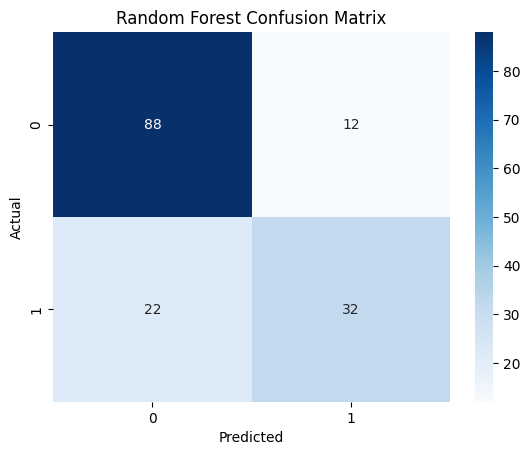

In [80]:
#confusion matrix
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [81]:
#Getting prediction probanilities
lr_probability = lr.predict_proba(X_test_scaled)[:, 1]

In [82]:
#Change the decision threshold
threshold = 0.40

lr_tuned_pred = (lr_probability >= threshold).astype(int)

In [83]:
print(classification_report(y_test, lr_tuned_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79       100
           1       0.61      0.65      0.63        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.73      0.74       154



In [84]:
recall_score(y_test, lr_tuned_pred)

0.6481481481481481

In [85]:
#Test several thresholds
thresholds = [0.5, 0.45, 0.40, 0.35, 0.30, 0.25]

for threshold in thresholds:

    pred = (lr_probability >= threshold).astype(int)

    print(
        "Threshold:",
        threshold,
        "Recall:",
        round(recall_score(y_test, pred), 3),
        "Precision:",
        round(precision_score(y_test, pred), 3),
        "F1:",
        round(f1_score(y_test, pred), 3)
    )

Threshold: 0.5 Recall: 0.5 Precision: 0.6 F1: 0.545
Threshold: 0.45 Recall: 0.556 Precision: 0.588 F1: 0.571
Threshold: 0.4 Recall: 0.648 Precision: 0.614 F1: 0.631
Threshold: 0.35 Recall: 0.685 Precision: 0.587 F1: 0.632
Threshold: 0.3 Recall: 0.796 Precision: 0.597 F1: 0.683
Threshold: 0.25 Recall: 0.87 Precision: 0.573 F1: 0.691


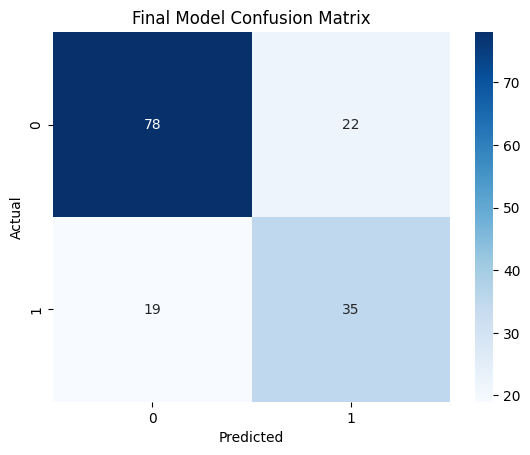

In [86]:
#Final confusion matrix
threshold = 0.40

final_pred = (lr_probability >= threshold).astype(int)

cm = confusion_matrix(y_test, final_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model Confusion Matrix")

plt.show()

In [87]:
#Final model report
print("Accuracy:",
      accuracy_score(y_test, final_pred))

print("Precision:",
      precision_score(y_test, final_pred))

print("Recall:",
      recall_score(y_test, final_pred))

print("F1 Score:",
      f1_score(y_test, final_pred))

Accuracy: 0.7337662337662337
Precision: 0.6140350877192983
Recall: 0.6481481481481481
F1 Score: 0.6306306306306306


In [89]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79       100
           1       0.61      0.65      0.63        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.73      0.74       154

